<a href="https://colab.research.google.com/github/akritivishwakarma2007/DE-journey/blob/main/File_handling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# file open, write
f = open('sample.txt', 'w')
f.write('hello, how are you?')
# f.close()

19

In [2]:
f.write('   hello')
f.close()


In [3]:
# write multiline strings
f = open('sample1.txt','w')
f.write('hello world')
f.write('\nhow are you?')
f.close()

In [4]:
#append in file
f = open('sample.txt', 'a')
f.write('\n I am Fine')
f.close()

In [5]:
#write lines
L = ['\nhello\n','hii\n', 'how are you?\n', 'All good?\n']
f = open('sample.txt', 'a')
f.writelines(L)
f.close()

In [6]:
#read files, reading upto n chars
f = open('sample.txt', 'r')
s = f.read(19)
print(s)


hello, how are you?


In [7]:
#readline -- to read line by line
f = open('sample.txt', 'r')
print(f.readline())
print(f.readline())
print(f.readline(), end='')
print(f.readline(), end='')

hello, how are you?   hello

 I am Fine

hello
hii


In [8]:
#reading entire using readline
f = open('sample.txt', 'r')
while True:

  data = f.readline()
  if data == '':
    break
  else:
    print(data, end = '')

f.close()

hello, how are you?   hello
 I am Fine
hello
hii
how are you?
All good?


### Using Context Manager (With)

- It's a good idea to close a file after usage as it will free up the resources
- If we dont close it, garbage collector would close it
- with keyword closes the file as soon as the usage is over

In [9]:
# with
with open('/content/sample1.txt','w') as f:
  f.write('Hello, how are you ')

In [11]:
f.write('hello')

ValueError: I/O operation on closed file.

In [12]:
with open('/content/sample.txt','r') as f:
  print(f.readline())

hello, how are you?   hello



In [13]:
# moving within a file -> 10 char then 10 char
with open('sample.txt','r') as f:
  print(f.read(10))
  print(f.read(10))
  print(f.read(10))
  print(f.read(10))

hello, how
 are you? 
  hello
 I
 am Fine
h


In [14]:
# benefit? -> to load a big file in memory
big_L = ['hello world ' for i in range(1000)]

with open('big.txt','w') as f:
  f.writelines(big_L)


In [15]:
with open('big.txt','r') as f:

  chunk_size = 10

  while len(f.read(chunk_size)) > 0:
    print(f.read(chunk_size),end='***')
    f.read(chunk_size)

d hello wo***o world he***d hello wo***o world he***d hello wo***o world he***d hello wo***o world he***d hello wo***o world he***d hello wo***o world he***d hello wo***o world he***d hello wo***o world he***d hello wo***o world he***d hello wo***o world he***d hello wo***o world he***d hello wo***o world he***d hello wo***o world he***d hello wo***o world he***d hello wo***o world he***d hello wo***o world he***d hello wo***o world he***d hello wo***o world he***d hello wo***o world he***d hello wo***o world he***d hello wo***o world he***d hello wo***o world he***d hello wo***o world he***d hello wo***o world he***d hello wo***o world he***d hello wo***o world he***d hello wo***o world he***d hello wo***o world he***d hello wo***o world he***d hello wo***o world he***d hello wo***o world he***d hello wo***o world he***d hello wo***o world he***d hello wo***o world he***d hello wo***o world he***d hello wo***o world he***d hello wo***o world he***d hello wo***o world he***d hello wo**

In [16]:
with open('sample.txt','r') as f:
  f.seek(15)
  print(f.read(10))
  print(f.tell())

  print(f.read(10))
  print(f.tell())

you?   hel
25
lo
 I am F
35


In [17]:
# seek during write
with open('sample.txt','w') as f:
  f.write('Hello')
  f.seek(0)
  f.write('Xa')

### Problems with working in text mode

- can't work with binary files like images
- not good for other data types like int/float/list/tuples

In [23]:
# working with binary file
with open('/content/photo.jpeg','r') as f:
  f.read()

UnicodeDecodeError: 'utf-8' codec can't decode byte 0xff in position 0: invalid start byte

In [24]:
# working with binary file
with open('/content/photo.jpeg','rb') as f:
  with open('/content/photo1.jpeg','wb') as wf:
    wf.write(f.read())

In [ ]:
# working with a big binary file

In [25]:
# working with other data types
with open('sample.txt','w') as f:
  f.write(5)

TypeError: write() argument must be str, not int

In [26]:
with open('sample.txt','w') as f:
  f.write('5')

In [27]:
with open('sample.txt','r') as f:
  print(int(f.read()) + 5)

10


In [37]:
# more complex data
d = {
    'name':'nitish',
     'age':33,
     'gender':'male'
}

with open('sample.txt','w') as f:
  f.write(str(d))

In [39]:
with open('sample.txt','r') as f:
  print(f.read())
  print(type(f.read()))

{'name': 'nitish', 'age': 33, 'gender': 'male'}
<class 'str'>


In [29]:
with open('sample.txt','r') as f:
  print(dict(f.read()))

ValueError: dictionary update sequence element #0 has length 1; 2 is required

### Serialization and Deserialization

- **Serialization** - process of converting python data types to JSON format
- **Deserialization** - process of converting JSON to python data types

#### What is JSON?

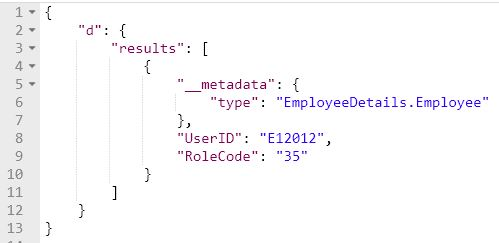

In [44]:
# serialization using json module
# list
import json

L = [1,2,3,4]

with open('demo.json','w') as f:
  json.dump(L,f)


In [45]:
# dict
d = {
    'name':'nitish',
     'age':33,
     'gender':'male'
}

with open('demo.json','w') as f:
  json.dump(d,f,indent=4)

In [46]:
# deserialization
import json

with open('demo.json','r') as f:
  d = json.load(f)
  print(d)
  print(type(d))

{'name': 'nitish', 'age': 33, 'gender': 'male'}
<class 'dict'>


In [47]:
# serialize and deserialize tuple
import json

t = (1,2,3,4,5)

with open('demo.json','w') as f:
  json.dump(t,f)

In [48]:
# serialize and deserialize a nested dict

d = {
    'student':'nitish',
     'marks':[23,14,34,45,56]
}

with open('demo.json','w') as f:
  json.dump(d,f)

### Serializing and Deserializing custom objects

In [54]:
class Person:

  def __init__(self,fname,lname,age,gender):
    self.fname = fname
    self.lname = lname
    self.age = age
    self.gender = gender

# format to printed in
# -> Nitish Singh age -> 33 gender -> male

In [55]:
person = Person('Nitish','Singh',33,'male')

In [56]:
# As a string
import json

def show_object(person):
  if isinstance(person,Person):
    return "{} {} age -> {} gender -> {}".format(person.fname,person.lname,person.age,person.gender)

with open('demo.json','w') as f:
  json.dump(person,f,default=show_object)

In [57]:
import json

with open('demo.json','r') as f:
  d = json.load(f)
  print(d)
  print(type(d))

Nitish Singh age -> 33 gender -> male
<class 'str'>


In [58]:
# As a dict
import json

def show_object(person):
  if isinstance(person,Person):
    return {'name':person.fname + ' ' + person.lname,'age':person.age,'gender':person.gender}

with open('demo.json','w') as f:
  json.dump(person,f,default=show_object,indent=4)

In [59]:
# deserializing
import json

with open('demo.json','r') as f:
  d = json.load(f)
  print(d)
  print(type(d))

{'name': 'Nitish Singh', 'age': 33, 'gender': 'male'}
<class 'dict'>


### Pickling
`Pickling` is the process whereby a Python object hierarchy is converted into a byte stream, and `unpickling` is the inverse operation, whereby a byte stream (from a binary file or bytes-like object) is converted back into an object hierarchy.

In [60]:
class Person:

  def __init__(self,name,age):
    self.name = name
    self.age = age

  def display_info(self):
    print('Hi my name is',self.name,'and I am ',self.age,'years old')

In [61]:
p = Person('nitish',33)

In [62]:
# pickle dump
import pickle
with open('person.pkl','wb') as f:
  pickle.dump(p,f)

In [63]:
# pickle load
import pickle
with open('person.pkl','rb') as f:
  p = pickle.load(f)

p.display_info()

Hi my name is nitish and I am  33 years old


### Pickle Vs Json

- Pickle lets the user to store data in binary format. JSON lets the user store data in a human-readable text format.